In [1]:
# Cell 1 — Imports and Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

df = pd.read_csv('../data/creditcard.csv')
print("Data loaded successfully!")
print("Shape:", df.shape)

Data loaded successfully!
Shape: (284807, 31)


In [2]:
# Cell 2 — Normalize Amount and Time
scaler = StandardScaler()

df['Normalized_Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['Normalized_Time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

# Drop original Amount and Time
df = df.drop(['Amount', 'Time'], axis=1)

print("After normalization:")
print(df.shape)
print("\nFirst 5 rows:")
df.head()


# ## What this does in simple language:

# **Before normalization:**
# ```
# Amount: 0.01 to 25,691 (huge range)
# Time:   0 to 172,792 (huge range)
# V1-V28: mostly between -5 to 5 (small range)
# ```

# **Problem:** Amount and Time have much larger numbers than V1-V28. Your model will think they are more important just because the numbers are bigger — which is wrong.

# **After normalization:**
# ```
# All features: roughly between -3 to 3

After normalization:
(284807, 31)

First 5 rows:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Normalized_Amount,Normalized_Time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964,-1.996583
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475,-1.996583
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686,-1.996562
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534,-1.996562
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403,-1.996541


In [3]:
# Cell 3 — Train/Test Split
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
                                    X, y, 
                                    test_size=0.2, 
                                    random_state=42,
                                    stratify=y)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nFraud cases in training set:", y_train.sum())
print("Fraud cases in testing set:", y_test.sum())


# Total data: 284,807 transactions
#      ↓
# 80% Training (227,845) → model learns from this
# 20% Testing  (56,962)  → model is evaluated on this

Training set size: (227845, 30)
Testing set size: (56962, 30)

Fraud cases in training set: 394
Fraud cases in testing set: 98


In [4]:
# Cell 4a — Install SMOTE
import sys
!{sys.executable} -m pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\karan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [5]:
# Cell 4b — Apply SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print("Normal transactions:", sum(y_train==0))
print("Fraud transactions:", sum(y_train==1))

print("\nAfter SMOTE:")
print("Normal transactions:", sum(y_train_smote==0))
print("Fraud transactions:", sum(y_train_smote==1))


# **Before SMOTE:**
# ```
# Normal: 227,451 transactions
# Fraud:      394 transactions  ← way too few
# ```

# **After SMOTE:**
# ```
# Normal: 227,451 transactions
# Fraud:  227,451 transactions  ← balanced!

Before SMOTE:
Normal transactions: 227451
Fraud transactions: 394

After SMOTE:
Normal transactions: 227451
Fraud transactions: 227451


In [6]:
# Cell 5 — Train Logistic Regression
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_smote, y_train_smote)

print("Model trained successfully!")

Model trained successfully!


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962


AUC-ROC Score: 0.9464


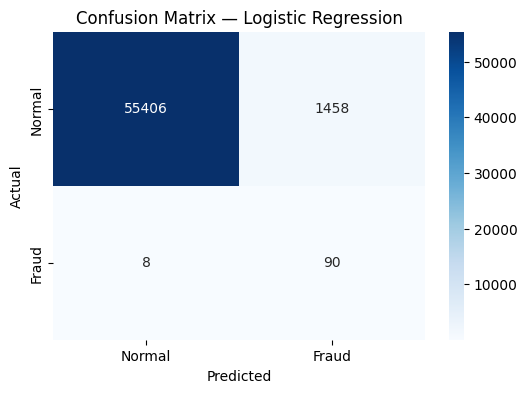

In [7]:
# Cell 6 — Evaluate Logistic Regression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = lr_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nAUC-ROC Score:", round(roc_auc_score(y_test, y_pred), 4))

# Confusion Matrix
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
plt.title('Confusion Matrix — Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()



# **Confusion Matrix — 4 boxes:**
# ```
# True Normal  (correctly said normal)  → want this HIGH
# False Fraud  (said fraud, was normal) → want this LOW
# False Normal (said normal, was fraud) → want this LOW ⚠️
# True Fraud   (correctly caught fraud) → want this HIGH

In [8]:
import sys
!{sys.executable} -m pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\karan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [9]:
import tensorflow as tf
from tensorflow import keras

In [10]:
# Cell 8 — Build Neural Network


model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train_smote.shape[1],)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

C:\Users\karan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Cell 8 — Build Neural Network
import tensorflow as tf
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train_smote.shape[1],)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Cell 9 — Train Neural Network
history = model.fit(
    X_train_smote, y_train_smote,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

print("Training complete!")



# epochs=20       → model sees entire dataset 20 times
# batch_size=32   → learns from 32 transactions at a time
# validation_split→ uses 20% of training data to check progress

Epoch 1/20
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - accuracy: 0.9990 - loss: 0.0044 - val_accuracy: 1.0000 - val_loss: 6.9080e-04
Epoch 2/20
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - accuracy: 0.9990 - loss: 0.0044 - val_accuracy: 1.0000 - val_loss: 8.1610e-04
Epoch 3/20
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - accuracy: 0.9991 - loss: 0.0043 - val_accuracy: 1.0000 - val_loss: 6.3042e-04
Epoch 4/20
 9443/11373 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9992 - loss: 0.0040

KeyboardInterrupt: 

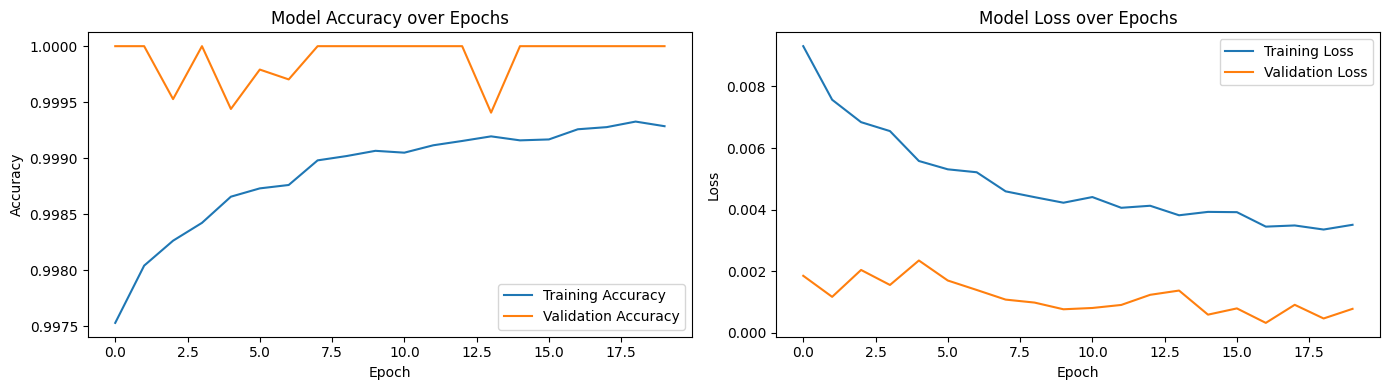

In [ ]:
# Cell 10 — Plot Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss plot
axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Neural Network Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.72      0.86      0.78        98

    accuracy                           1.00     56962
   macro avg       0.86      0.93      0.89     56962
weighted avg       1.00      1.00      1.00     56962


AUC-ROC Score: 0.9283


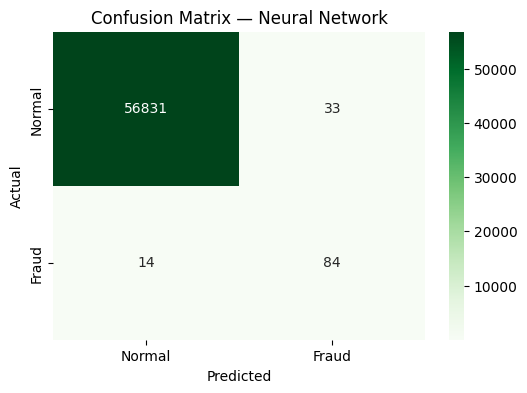

In [ ]:
# Cell 11 — Evaluate Neural Network
y_pred_nn = (model.predict(X_test) > 0.5).astype(int)

print("Neural Network Results:")
print(classification_report(y_test, y_pred_nn))

print("\nAUC-ROC Score:", round(roc_auc_score(y_test, y_pred_nn), 4))

# Confusion Matrix
plt.figure(figsize=(6,4))
cm_nn = confusion_matrix(y_test, y_pred_nn)
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
plt.title('Confusion Matrix — Neural Network')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
# Cell 12 — Save the Model
model.save('../model/fraud_model.h5')
print("Model saved successfully!")

Model saved successfully!


In [ ]:
import sys
!{sys.executable} -m pip install shap

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/556.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/556.1 kB ? eta -:--:--
   ------------------ --------------------- 262.1/556.1 kB ? eta -:--:--
   ----------------------------------- -- 524.3/556.1 kB 837.5 kB/s eta 0:00:01
   -------------------------------------- 556.1/556.1 kB 854.6 kB/s eta 0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.1 MB ? eta -:--:--
    --------------------------------------- 0.5/38.1 MB 1.3 MB/s eta 0:00:30
   - -------------------------------------- 1.0/38.1 MB 1.9 MB/s eta 0:00:20
   - -------------------------------------- 1.3/38.1 MB 1.7 MB/s eta 0:00:22
   - -------------------------------------- 1.8/38.1 MB 1.9 MB/s eta 0:00:20
   - -------------------------------------- 1.8/38.1 MB 1.9 MB/s eta 0:00:20
   -- ----------------


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\karan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
# Cell 14 — SHAP Explainability
import shap
import numpy as np

# Use a small sample for SHAP (full dataset is too slow)
X_sample = X_test.iloc[:100]

# Create SHAP explainer
explainer = shap.KernelExplainer(model.predict, 
                                  shap.sample(X_train_smote, 100))

print("Explainer created successfully!")


# > *"Your model said this transaction is fraud — but WHY?"*

# SHAP answers this by calculating how much each feature **contributed** to the final decision.

# Example output:
# ```
# V14 pushed prediction toward FRAUD   → +0.35
# V17 pushed prediction toward FRAUD   → +0.28
# Amount pushed prediction toward NORMAL → -0.12

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Explainer created successfully!


In [ ]:
# Cell 15 — Generate SHAP Values
shap_values = explainer.shap_values(X_sample)
print("SHAP values generated!")

  0%|          | 0/100 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


  1%|          | 1/100 [00:13<22:41, 13.75s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step


  2%|▏         | 2/100 [00:27<22:07, 13.55s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step


  3%|▎         | 3/100 [00:41<22:19, 13.81s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step


  4%|▍         | 4/100 [00:56<23:10, 14.49s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step


  5%|▌         | 5/100 [01:17<26:39, 16.84s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step


  6%|▌         | 6/100 [01:32<25:24, 16.22s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step


  7%|▋         | 7/100 [01:47<24:32, 15.83s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step


  8%|▊         | 8/100 [02:10<27:40, 18.05s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 26s 4ms/step


  9%|▉         | 9/100 [02:44<34:53, 23.01s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 29s 4ms/step


 10%|█         | 10/100 [03:20<40:24, 26.93s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step


 11%|█         | 11/100 [03:51<41:55, 28.27s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step


 12%|█▏        | 12/100 [04:15<39:43, 27.09s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step


 13%|█▎        | 13/100 [04:36<36:34, 25.23s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step


 14%|█▍        | 14/100 [04:51<31:31, 22.00s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step


 15%|█▌        | 15/100 [05:08<29:14, 20.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step


 16%|█▌        | 16/100 [05:34<30:49, 22.02s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step


 17%|█▋        | 17/100 [06:01<32:30, 23.50s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step


 18%|█▊        | 18/100 [06:31<34:54, 25.54s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step


 19%|█▉        | 19/100 [07:00<35:54, 26.60s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step


 20%|██        | 20/100 [07:31<37:06, 27.83s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step


 21%|██        | 21/100 [07:58<36:37, 27.81s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step


 22%|██▏       | 22/100 [08:12<30:28, 23.44s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step


 23%|██▎       | 23/100 [08:25<26:11, 20.40s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step


 24%|██▍       | 24/100 [08:39<23:19, 18.41s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step


 25%|██▌       | 25/100 [08:51<20:34, 16.47s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step


 26%|██▌       | 26/100 [09:04<19:03, 15.45s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step


 27%|██▋       | 27/100 [09:16<17:38, 14.50s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step


 28%|██▊       | 28/100 [09:30<17:08, 14.29s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step


 29%|██▉       | 29/100 [09:43<16:39, 14.08s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step


 30%|███       | 30/100 [10:04<18:49, 16.14s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


 31%|███       | 31/100 [10:17<17:20, 15.07s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step


 32%|███▏      | 32/100 [10:30<16:18, 14.39s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step


 33%|███▎      | 33/100 [10:42<15:14, 13.65s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step


 34%|███▍      | 34/100 [10:54<14:42, 13.36s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step


 35%|███▌      | 35/100 [11:05<13:37, 12.58s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


 36%|███▌      | 36/100 [11:17<13:18, 12.47s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


 37%|███▋      | 37/100 [11:30<13:03, 12.44s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


 38%|███▊      | 38/100 [11:42<12:46, 12.37s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step


 39%|███▉      | 39/100 [11:55<12:47, 12.58s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step


 40%|████      | 40/100 [12:07<12:29, 12.49s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step


 41%|████      | 41/100 [12:21<12:34, 12.78s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step


 42%|████▏     | 42/100 [12:42<14:43, 15.23s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step


 43%|████▎     | 43/100 [12:55<13:56, 14.68s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step


 44%|████▍     | 44/100 [13:16<15:26, 16.55s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


 45%|████▌     | 45/100 [13:29<14:05, 15.36s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step


 46%|████▌     | 46/100 [13:40<12:51, 14.29s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step


 47%|████▋     | 47/100 [13:52<11:51, 13.43s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step


 48%|████▊     | 48/100 [14:04<11:18, 13.05s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step


 49%|████▉     | 49/100 [14:17<11:04, 13.02s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


 50%|█████     | 50/100 [14:29<10:42, 12.85s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step


 51%|█████     | 51/100 [14:41<10:18, 12.62s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step


 52%|█████▏    | 52/100 [14:55<10:19, 12.90s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step


 53%|█████▎    | 53/100 [15:15<11:50, 15.11s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step


 54%|█████▍    | 54/100 [15:34<12:20, 16.11s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step


 55%|█████▌    | 55/100 [15:53<12:53, 17.19s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step


 56%|█████▌    | 56/100 [16:09<12:09, 16.57s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step


 57%|█████▋    | 57/100 [16:19<10:26, 14.58s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step


 58%|█████▊    | 58/100 [16:31<09:41, 13.83s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step


 59%|█████▉    | 59/100 [16:42<08:58, 13.14s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step


 60%|██████    | 60/100 [16:55<08:37, 12.93s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step


 61%|██████    | 61/100 [17:16<09:57, 15.33s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step


 62%|██████▏   | 62/100 [17:29<09:25, 14.88s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step


 63%|██████▎   | 63/100 [17:43<08:57, 14.52s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step


 64%|██████▍   | 64/100 [17:54<08:06, 13.51s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step


 65%|██████▌   | 65/100 [18:05<07:27, 12.79s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step


 66%|██████▌   | 66/100 [18:15<06:43, 11.88s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step


 67%|██████▋   | 67/100 [18:28<06:38, 12.08s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step


 68%|██████▊   | 68/100 [18:37<06:02, 11.32s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step


 69%|██████▉   | 69/100 [18:48<05:44, 11.10s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step


 70%|███████   | 70/100 [18:59<05:37, 11.26s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step


 71%|███████   | 71/100 [19:10<05:21, 11.10s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step


 72%|███████▏  | 72/100 [19:22<05:15, 11.27s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step


 73%|███████▎  | 73/100 [19:34<05:10, 11.48s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step


 74%|███████▍  | 74/100 [19:46<05:03, 11.69s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step


 75%|███████▌  | 75/100 [19:57<04:51, 11.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step


 76%|███████▌  | 76/100 [20:11<04:54, 12.28s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step


 77%|███████▋  | 77/100 [20:25<04:53, 12.78s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step


 78%|███████▊  | 78/100 [20:39<04:50, 13.21s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step


 79%|███████▉  | 79/100 [20:54<04:45, 13.60s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step


 80%|████████  | 80/100 [21:07<04:29, 13.48s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step


 81%|████████  | 81/100 [21:20<04:12, 13.31s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step


 82%|████████▏ | 82/100 [21:41<04:40, 15.60s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step


 83%|████████▎ | 83/100 [22:02<04:52, 17.22s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step


 84%|████████▍ | 84/100 [22:16<04:21, 16.36s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step


 85%|████████▌ | 85/100 [22:30<03:54, 15.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step


 86%|████████▌ | 86/100 [22:44<03:31, 15.13s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step


 87%|████████▋ | 87/100 [22:58<03:11, 14.75s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step


 88%|████████▊ | 88/100 [23:12<02:53, 14.45s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step


 89%|████████▉ | 89/100 [23:26<02:36, 14.26s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step


 90%|█████████ | 90/100 [23:40<02:22, 14.28s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step


 91%|█████████ | 91/100 [23:54<02:08, 14.31s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step


 92%|█████████▏| 92/100 [24:09<01:54, 14.30s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step


 93%|█████████▎| 93/100 [24:23<01:39, 14.28s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step


 94%|█████████▍| 94/100 [24:37<01:25, 14.29s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step


 95%|█████████▌| 95/100 [24:51<01:10, 14.11s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step


 96%|█████████▌| 96/100 [25:05<00:56, 14.02s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step


 97%|█████████▋| 97/100 [25:18<00:41, 13.91s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step


 98%|█████████▊| 98/100 [25:32<00:27, 13.82s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step


 99%|█████████▉| 99/100 [25:46<00:13, 13.85s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
6588/6588 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step


100%|██████████| 100/100 [25:59<00:00, 15.60s/it]

SHAP values generated!


Raw SHAP shape: (100, 30, 1)
X_sample shape: (100, 30)
Fixed SHAP shape: (100, 30)


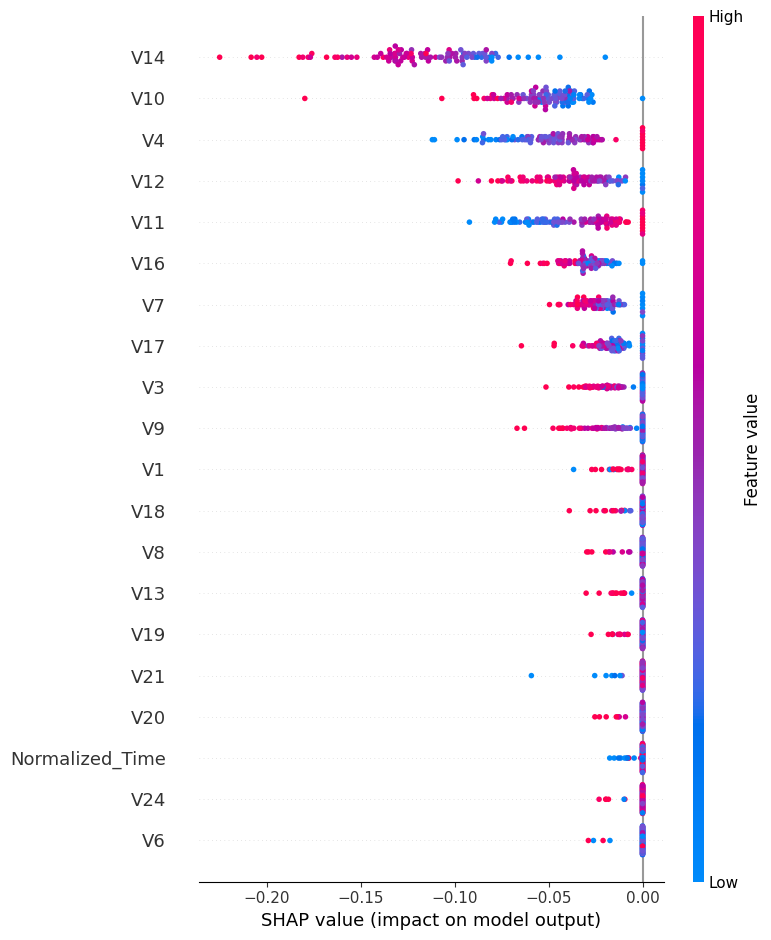

In [ ]:
# Cell 16 Fixed
import numpy as np

shap_vals = np.array(shap_values)
print("Raw SHAP shape:", shap_vals.shape)
print("X_sample shape:", X_sample.shape)

# Fix shape
if len(shap_vals.shape) == 3:
    shap_vals = shap_vals[:, :, 0]

print("Fixed SHAP shape:", shap_vals.shape)

shap.summary_plot(shap_vals, X_sample,
                  feature_names=X_test.columns.tolist(),
                  show=True)

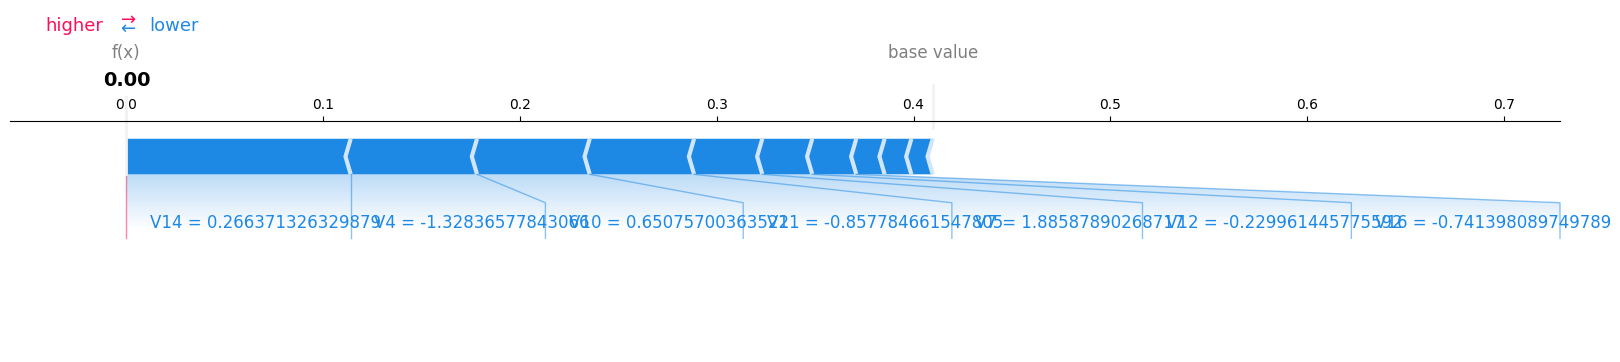

In [ ]:
# Cell 17 — Explain Single Transaction
shap.initjs()
shap.force_plot(explainer.expected_value[0],
                shap_vals[0],
                X_sample.iloc[0],
                feature_names=X_test.columns.tolist(),
                matplotlib=True)

In [ ]:
# Cell 18 Save SHAP values only
import numpy as np

np.save('../model/shap_values.npy', shap_vals)
print("SHAP values saved!")

model.save('../model/fraud_model.h5')
print("Model saved!")

SHAP values saved!
Model saved!


In [14]:
import pickle
with open('../model/lr_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)
print("LR model saved!")

LR model saved!
